# 🦷 OralGuard AI - Phase 3: Vision Transformer (ViT-B/16) Training Pipeline
## Oral Cancer Histopathology Classification System

**Objective**: Train separate ViT-B/16 models for 100x and 400x magnifications and compare with Phase 1 & 2

**Key Features**:
- Vision Transformer (ViT-B/16) with attention mechanisms
- Batch size 6 optimized for T4 GPU memory
- Learning rate 3e-5 with 5-epoch warmup scheduler
- Resume-friendly design (loads all previous phase results)
- Comprehensive 3-model comparison (EfficientNet-B5 vs VGG16 vs ViT)
- Same proven data pipeline from Phase 1 & 2
- Saves predictions for ensemble building (Phase 4)
- Standalone notebook (runs independently)

## 📦 1. Setup and Imports

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install required packages
!pip install -q timm scikit-learn matplotlib seaborn pandas numpy Pillow tqdm

print("✅ Packages installed!")
print("   - timm: For Vision Transformer models")
print("   - Other standard ML/DL packages")

✅ Packages installed!
   - timm: For Vision Transformer models
   - Other standard ML/DL packages


In [3]:
# Core imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Deep learning imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm  # PyTorch Image Models - for ViT

# Image processing
from PIL import Image
import cv2

# ML utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, accuracy_score
)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ timm version: {timm.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

✅ PyTorch version: 2.8.0+cu126
✅ timm version: 1.0.20
✅ CUDA available: True
✅ GPU: Tesla T4
✅ GPU Memory: 15.83 GB


## ⚙️ 2. Configuration

In [4]:
class Config:
    """Centralized configuration for OralGuard AI Phase 3 training"""

    # Paths
    BASE_PATH = '/content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/Histopathological_Oral_Cancer'
    OUTPUT_DIR = '/content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-3'
    PHASE1_RESULTS = '/content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-1'
    PHASE2_RESULTS = '/content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-2'

    # Data structure
    MAGNIFICATIONS = {
        '100x': {
            'normal': 'First Set/100x_Normal',
            'oscc': 'First Set/100x_OSCC'
        },
        '400x': {
            'normal': 'Second Set/400x_Normal',
            'oscc': 'Second Set/400x_OSCC'
        }
    }

    # Model settings
    MODEL_NAME = 'vit_base_patch16_224'  # ViT-B/16
    IMG_SIZE = 224
    NUM_CLASSES = 2

    # Training hyperparameters (optimized for ViT on T4 GPU)
    BATCH_SIZE = 6  # Reduced for ViT's memory requirements
    EPOCHS = 50
    LEARNING_RATE = 3e-5  # Lower for ViT fine-tuning
    WEIGHT_DECAY = 1e-4
    WARMUP_EPOCHS = 5  # NEW: Warmup for ViT

    # Data split
    TRAIN_SPLIT = 0.8
    VAL_SPLIT = 0.1
    TEST_SPLIT = 0.1
    RANDOM_SEED = 42

    # Early stopping
    PATIENCE = 10
    MIN_DELTA = 0.001

    # Mixed precision training for T4 GPU
    USE_AMP = True

    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Class names
    CLASS_NAMES = ['Normal', 'OSCC']

config = Config()

# Create output directory
os.makedirs(config.OUTPUT_DIR, exist_ok=True)
print(f"✅ Configuration loaded")
print(f"📁 Output directory: {config.OUTPUT_DIR}")
print(f"📁 Phase 1 results: {config.PHASE1_RESULTS}")
print(f"📁 Phase 2 results: {config.PHASE2_RESULTS}")
print(f"🎯 Device: {config.DEVICE}")
print(f"🏗️ Model: Vision Transformer (ViT-B/16)")
print(f"📦 Batch size: {config.BATCH_SIZE} (optimized for ViT on T4)")
print(f"🔥 Learning rate: {config.LEARNING_RATE} with {config.WARMUP_EPOCHS}-epoch warmup")

✅ Configuration loaded
📁 Output directory: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-3
📁 Phase 1 results: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-1
📁 Phase 2 results: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-2
🎯 Device: cuda
🏗️ Model: Vision Transformer (ViT-B/16)
📦 Batch size: 6 (optimized for ViT on T4)
🔥 Learning rate: 3e-05 with 5-epoch warmup


## 📊 3. Data Loading and Preparation (Same as Phase 1 & 2)

In [5]:
def load_dataset(base_path, magnification):
    """
    Load dataset for specific magnification level

    Args:
        base_path: Base directory path
        magnification: '100x' or '400x'

    Returns:
        DataFrame with image paths and labels
    """
    data = []
    mag_config = config.MAGNIFICATIONS[magnification]

    # Load Normal images
    normal_path = os.path.join(base_path, mag_config['normal'])
    if os.path.exists(normal_path):
        for img_file in os.listdir(normal_path):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                data.append({
                    'image_path': os.path.join(normal_path, img_file),
                    'label': 0,  # Normal
                    'label_name': 'Normal',
                    'magnification': magnification
                })

    # Load OSCC images
    oscc_path = os.path.join(base_path, mag_config['oscc'])
    if os.path.exists(oscc_path):
        for img_file in os.listdir(oscc_path):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
                data.append({
                    'image_path': os.path.join(oscc_path, img_file),
                    'label': 1,  # OSCC
                    'label_name': 'OSCC',
                    'magnification': magnification
                })

    df = pd.DataFrame(data)
    print(f"\n📊 {magnification} Dataset:")
    print(f"  Total images: {len(df)}")
    print(f"  Normal: {len(df[df['label']==0])}")
    print(f"  OSCC: {len(df[df['label']==1])}")
    print(f"  Class ratio (OSCC:Normal): {len(df[df['label']==1])/len(df[df['label']==0]):.2f}:1")

    return df

# Load both datasets
print("="*80)
print("Loading datasets...")
print("="*80)

df_100x = load_dataset(config.BASE_PATH, '100x')
df_400x = load_dataset(config.BASE_PATH, '400x')

print(f"\n✅ Datasets loaded successfully!")

Loading datasets...

📊 100x Dataset:
  Total images: 528
  Normal: 89
  OSCC: 439
  Class ratio (OSCC:Normal): 4.93:1

📊 400x Dataset:
  Total images: 696
  Normal: 201
  OSCC: 495
  Class ratio (OSCC:Normal): 2.46:1

✅ Datasets loaded successfully!


In [6]:
def create_stratified_split(df, train_size=0.8, val_size=0.1, test_size=0.1, random_state=42):
    """
    Create stratified train/val/test split

    Args:
        df: DataFrame with image paths and labels
        train_size: Proportion for training (0.8 = 80%)
        val_size: Proportion for validation (0.1 = 10%)
        test_size: Proportion for testing (0.1 = 10%)
        random_state: Random seed for reproducibility

    Returns:
        train_df, val_df, test_df
    """
    # First split: separate test set
    train_val_df, test_df = train_test_split(
        df,
        test_size=test_size,
        stratify=df['label'],
        random_state=random_state
    )

    # Second split: separate validation from training
    val_ratio = val_size / (train_size + val_size)
    train_df, val_df = train_test_split(
        train_val_df,
        test_size=val_ratio,
        stratify=train_val_df['label'],
        random_state=random_state
    )

    print(f"\n📊 Data Split:")
    print(f"  Training:   {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
    print(f"  Validation: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
    print(f"  Testing:    {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

    # Verify stratification
    for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
        normal_count = len(split_df[split_df['label']==0])
        oscc_count = len(split_df[split_df['label']==1])
        print(f"  {split_name}: Normal={normal_count}, OSCC={oscc_count}")

    return train_df, val_df, test_df

# Create splits for both magnifications
print("\n" + "="*80)
print("Creating stratified splits...")
print("="*80)

print("\n🔬 100x Magnification:")
train_100x, val_100x, test_100x = create_stratified_split(
    df_100x,
    train_size=config.TRAIN_SPLIT,
    val_size=config.VAL_SPLIT,
    test_size=config.TEST_SPLIT,
    random_state=config.RANDOM_SEED
)

print("\n🔬 400x Magnification:")
train_400x, val_400x, test_400x = create_stratified_split(
    df_400x,
    train_size=config.TRAIN_SPLIT,
    val_size=config.VAL_SPLIT,
    test_size=config.TEST_SPLIT,
    random_state=config.RANDOM_SEED
)


Creating stratified splits...

🔬 100x Magnification:

📊 Data Split:
  Training:   422 (79.9%)
  Validation: 53 (10.0%)
  Testing:    53 (10.0%)
  Train: Normal=71, OSCC=351
  Val: Normal=9, OSCC=44
  Test: Normal=9, OSCC=44

🔬 400x Magnification:

📊 Data Split:
  Training:   556 (79.9%)
  Validation: 70 (10.1%)
  Testing:    70 (10.1%)
  Train: Normal=161, OSCC=395
  Val: Normal=20, OSCC=50
  Test: Normal=20, OSCC=50


## 🔄 4. Data Augmentation and Transforms (Same as Phase 1 & 2)

In [7]:
def get_transforms(mode='train'):
    """
    Get data augmentation transforms

    Args:
        mode: 'train' for augmentation, 'val' or 'test' for standard preprocessing

    Returns:
        torchvision transforms composition
    """
    # ImageNet normalization stats (for transfer learning)
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

    if mode == 'train':
        # Aggressive augmentation for class imbalance
        return transforms.Compose([
            transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=20),
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.1
            ),
            transforms.RandomResizedCrop(
                config.IMG_SIZE,
                scale=(0.8, 1.0),
                ratio=(0.9, 1.1)
            ),
            transforms.ToTensor(),
            normalize
        ])
    else:
        # Standard preprocessing for validation/test
        return transforms.Compose([
            transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
            transforms.ToTensor(),
            normalize
        ])

print("✅ Transforms defined (same as Phase 1 & 2):")
print("  - Training: Rotation, Flipping, Brightness, Cropping, Resizing")
print("  - Val/Test: Resize + Normalization only")

✅ Transforms defined (same as Phase 1 & 2):
  - Training: Rotation, Flipping, Brightness, Cropping, Resizing
  - Val/Test: Resize + Normalization only


In [8]:
class OralCancerDataset(Dataset):
    """
    Custom dataset for oral cancer histopathology images
    """
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, 'image_path']
        label = self.dataframe.loc[idx, 'label']

        # Load image
        image = Image.open(img_path).convert('RGB')

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        return image, label

print("✅ Custom Dataset class created")

✅ Custom Dataset class created


## 🏗️ 5. Vision Transformer (ViT-B/16) Model Architecture

In [9]:
class OralGuardViT(nn.Module):
    """
    Vision Transformer (ViT-B/16) for oral cancer classification
    """
    def __init__(self, num_classes=2, pretrained=True):
        super(OralGuardViT, self).__init__()

        # Load pretrained ViT-B/16
        self.backbone = timm.create_model(
            'vit_base_patch16_224',
            pretrained=pretrained,
            num_classes=0  # Remove classification head
        )

        # Get the embedding dimension
        embed_dim = self.backbone.embed_dim  # 768 for ViT-B

        # Custom classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(0.3),
            nn.Linear(embed_dim, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Get features from ViT backbone
        features = self.backbone(x)

        # Classification
        output = self.classifier(features)

        return output

# Test model creation
print("Creating test ViT model...")
test_model = OralGuardViT(num_classes=config.NUM_CLASSES)
print(f"\n✅ OralGuard Vision Transformer Architecture:")
print(f"  - Backbone: ViT-B/16 (pretrained on ImageNet-21k)")
print(f"  - Patch size: 16×16")
print(f"  - Input size: {config.IMG_SIZE}×{config.IMG_SIZE}")
print(f"  - Embedding dimension: 768")
print(f"  - Attention heads: 12")
print(f"  - Transformer layers: 12")
print(f"  - Output classes: {config.NUM_CLASSES}")
print(f"  - Total parameters: {sum(p.numel() for p in test_model.parameters()):,}")
print(f"  - Trainable parameters: {sum(p.numel() for p in test_model.parameters() if p.requires_grad):,}")
del test_model

Creating test ViT model...


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


✅ OralGuard Vision Transformer Architecture:
  - Backbone: ViT-B/16 (pretrained on ImageNet-21k)
  - Patch size: 16×16
  - Input size: 224×224
  - Embedding dimension: 768
  - Attention heads: 12
  - Transformer layers: 12
  - Output classes: 2
  - Total parameters: 86,194,946
  - Trainable parameters: 86,194,946


## ⚖️ 6. Class Weights Calculation

In [10]:
def calculate_class_weights(dataframe):
    """
    Calculate class weights for imbalanced dataset

    Args:
        dataframe: DataFrame with 'label' column

    Returns:
        torch tensor with class weights
    """
    class_counts = dataframe['label'].value_counts().sort_index().values
    total = len(dataframe)

    # Inverse frequency weighting
    weights = total / (len(class_counts) * class_counts)
    weights = torch.FloatTensor(weights)

    print(f"\n⚖️ Class Weights:")
    for i, (class_name, weight, count) in enumerate(zip(config.CLASS_NAMES, weights, class_counts)):
        print(f"  {class_name}: {weight:.4f} (n={count})")

    return weights

# Calculate weights for both magnifications
print("Calculating class weights for training sets...")
print("\n100x Magnification:")
weights_100x = calculate_class_weights(train_100x)

print("\n400x Magnification:")
weights_400x = calculate_class_weights(train_400x)

Calculating class weights for training sets...

100x Magnification:

⚖️ Class Weights:
  Normal: 2.9718 (n=71)
  OSCC: 0.6011 (n=351)

400x Magnification:

⚖️ Class Weights:
  Normal: 1.7267 (n=161)
  OSCC: 0.7038 (n=395)


## 🔥 7. Warmup Learning Rate Scheduler (NEW for ViT)

In [11]:
class WarmupLRScheduler:
    """
    Learning rate warmup scheduler for Vision Transformer
    Gradually increases learning rate from 0 to target LR over warmup_epochs
    """
    def __init__(self, optimizer, warmup_epochs, initial_lr, target_lr):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.initial_lr = initial_lr
        self.target_lr = target_lr
        self.current_epoch = 0

    def step(self, epoch):
        """
        Update learning rate based on current epoch
        """
        self.current_epoch = epoch

        if epoch < self.warmup_epochs:
            # Linear warmup
            lr = self.initial_lr + (self.target_lr - self.initial_lr) * (epoch / self.warmup_epochs)
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = lr
            return lr
        else:
            # Return target LR after warmup
            return self.target_lr

    def get_last_lr(self):
        """Get current learning rate"""
        return [param_group['lr'] for param_group in self.optimizer.param_groups]

print(f"✅ Warmup scheduler defined:")
print(f"  - Warmup epochs: {config.WARMUP_EPOCHS}")
print(f"  - Initial LR: 0")
print(f"  - Target LR: {config.LEARNING_RATE}")
print(f"  - Strategy: Linear warmup")

✅ Warmup scheduler defined:
  - Warmup epochs: 5
  - Initial LR: 0
  - Target LR: 3e-05
  - Strategy: Linear warmup


## 🎯 8. Training Functions (Enhanced for Warmup)

In [12]:
def train_epoch(model, dataloader, criterion, optimizer, device, scaler=None):
    """
    Train for one epoch
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc='Training', leave=False)

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Mixed precision training
        if scaler is not None:
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc


def validate_epoch(model, dataloader, criterion, device):
    """
    Validate for one epoch
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation', leave=False)

        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            # Store for metrics
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            probs = torch.softmax(outputs, dim=1)
            all_probs.extend(probs[:, 1].cpu().numpy())  # Probability of OSCC class

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc, all_labels, all_preds, all_probs

print("✅ Training functions defined")

✅ Training functions defined


In [13]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                warmup_scheduler, main_scheduler, device, num_epochs, model_name, save_dir):
    """
    Complete training loop with warmup, early stopping, and checkpointing
    """
    # Mixed precision scaler
    scaler = torch.cuda.amp.GradScaler() if config.USE_AMP else None

    # Training history
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'learning_rates': []
    }

    # Early stopping
    best_val_acc = 0.0
    patience_counter = 0
    best_model_path = os.path.join(save_dir, f'{model_name}_best.pth')

    print(f"\n{'='*80}")
    print(f"🚀 Starting Training: {model_name}")
    print(f"{'='*80}")
    print(f"Training samples: {len(train_loader.dataset)}")
    print(f"Validation samples: {len(val_loader.dataset)}")
    print(f"Batch size: {config.BATCH_SIZE}")
    print(f"Epochs: {num_epochs}")
    print(f"Learning rate: {config.LEARNING_RATE} (with {config.WARMUP_EPOCHS}-epoch warmup)")
    print(f"Mixed precision: {config.USE_AMP}")
    print(f"{'='*80}\n")

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 50)

        # Update warmup scheduler (first warmup_epochs epochs)
        if epoch < config.WARMUP_EPOCHS:
            current_lr = warmup_scheduler.step(epoch)
            print(f"🔥 Warmup Phase: LR = {current_lr:.2e}")

        # Train
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device, scaler
        )

        # Validate
        val_loss, val_acc, _, _, _ = validate_epoch(
            model, val_loader, criterion, device
        )

        # Update main scheduler (after warmup)
        if epoch >= config.WARMUP_EPOCHS:
            main_scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']

        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['learning_rates'].append(current_lr)

        # Print metrics
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        print(f"Learning Rate: {current_lr:.2e}")

        # Check for improvement
        if val_acc > best_val_acc + config.MIN_DELTA:
            best_val_acc = val_acc
            patience_counter = 0

            # Save best model
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_loss': val_loss,
            }, best_model_path)
            print(f"✅ New best model saved! Val Acc: {val_acc:.2f}%")
        else:
            patience_counter += 1
            print(f"⏳ Patience: {patience_counter}/{config.PATIENCE}")

        # Early stopping
        if patience_counter >= config.PATIENCE:
            print(f"\n⏹️ Early stopping triggered at epoch {epoch+1}")
            break

    print(f"\n{'='*80}")
    print(f"✅ Training completed!")
    print(f"Best validation accuracy: {best_val_acc:.2f}%")
    print(f"Best model saved at: {best_model_path}")
    print(f"{'='*80}\n")

    # Load best model
    checkpoint = torch.load(best_model_path)
    model.load_state_dict(checkpoint['model_state_dict'])

    return model, history

print("✅ Complete training pipeline with warmup ready")

✅ Complete training pipeline with warmup ready


## 📈 9. Evaluation Functions (Enhanced for Ensemble Prep)

In [14]:
def evaluate_model(model, dataloader, device, save_path=None, save_predictions=False, pred_save_path=None):
    """
    Comprehensive model evaluation with option to save predictions for ensemble
    """
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Evaluating'):
            images = images.to(device)
            outputs = model(images)

            _, predicted = outputs.max(1)
            probs = torch.softmax(outputs, dim=1)

            all_labels.extend(labels.numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    # For binary classification, extract OSCC probabilities
    all_probs_array = np.array(all_probs)
    oscc_probs = all_probs_array[:, 1]  # Probability of OSCC class
    auc = roc_auc_score(all_labels, oscc_probs)

    # Classification report
    report = classification_report(
        all_labels, all_preds,
        target_names=config.CLASS_NAMES,
        output_dict=True
    )

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    results = {
        'accuracy': accuracy,
        'f1_score': f1,
        'auc_roc': auc,
        'classification_report': report,
        'confusion_matrix': cm,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': oscc_probs
    }

    # Print results
    print(f"\n{'='*80}")
    print("📊 Evaluation Results")
    print(f"{'='*80}")
    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"F1 Score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"\n{classification_report(all_labels, all_preds, target_names=config.CLASS_NAMES)}")

    # Save results
    if save_path:
        results_to_save = {
            'accuracy': float(accuracy),
            'f1_score': float(f1),
            'auc_roc': float(auc),
            'classification_report': report,
            'confusion_matrix': cm.tolist()
        }
        with open(save_path, 'w') as f:
            json.dump(results_to_save, f, indent=4)
        print(f"\n✅ Results saved to: {save_path}")

    # Save predictions for ensemble building
    if save_predictions and pred_save_path:
        predictions_data = {
            'labels': [int(x) for x in all_labels],
            'predictions': [int(x) for x in all_preds],
            'probabilities': all_probs_array.tolist()
        }
        with open(pred_save_path, 'w') as f:
            json.dump(predictions_data, f, indent=4)
        print(f"✅ Predictions saved for ensemble: {pred_save_path}")

    return results

print("✅ Enhanced evaluation functions ready (with ensemble prep)")

✅ Enhanced evaluation functions ready (with ensemble prep)


## 📊 10. Visualization Functions

In [15]:
def plot_training_history(history, save_path=None):
    """
    Plot training and validation metrics
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot loss
    axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # Plot accuracy
    axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2)
    axes[1].plot(history['val_acc'], label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    # Plot learning rate with warmup annotation
    axes[2].plot(history['learning_rates'], linewidth=2, color='red')
    axes[2].axvline(x=config.WARMUP_EPOCHS, color='blue', linestyle='--',
                    linewidth=2, label=f'Warmup End (Epoch {config.WARMUP_EPOCHS})')
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('Learning Rate', fontsize=12)
    axes[2].set_title('Learning Rate Schedule with Warmup', fontsize=14, fontweight='bold')
    axes[2].legend(fontsize=11)
    axes[2].set_yscale('log')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


def plot_confusion_matrix(cm, save_path=None):
    """
    Plot confusion matrix
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=config.CLASS_NAMES,
        yticklabels=config.CLASS_NAMES,
        cbar_kws={'label': 'Count'}
    )
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold')

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


def plot_roc_curve(labels, probs, save_path=None):
    """
    Plot ROC curve
    """
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curve', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

print("✅ Visualization functions ready")

✅ Visualization functions ready


## 🎓 11. Train 100x ViT Model

In [16]:
# Create dataloaders for 100x
print("Creating dataloaders for 100x magnification...")

train_dataset_100x = OralCancerDataset(train_100x, transform=get_transforms('train'))
val_dataset_100x = OralCancerDataset(val_100x, transform=get_transforms('val'))
test_dataset_100x = OralCancerDataset(test_100x, transform=get_transforms('test'))

train_loader_100x = DataLoader(
    train_dataset_100x,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader_100x = DataLoader(
    val_dataset_100x,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader_100x = DataLoader(
    test_dataset_100x,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"✅ Dataloaders created:")
print(f"  Train batches: {len(train_loader_100x)}")
print(f"  Val batches: {len(val_loader_100x)}")
print(f"  Test batches: {len(test_loader_100x)}")

Creating dataloaders for 100x magnification...
✅ Dataloaders created:
  Train batches: 71
  Val batches: 9
  Test batches: 9


In [17]:
# Initialize model for 100x
print("Initializing 100x ViT model...")

model_100x = OralGuardViT(num_classes=config.NUM_CLASSES, pretrained=True)
model_100x = model_100x.to(config.DEVICE)

# Loss function with class weights
criterion_100x = nn.CrossEntropyLoss(weight=weights_100x.to(config.DEVICE))

# Optimizer
optimizer_100x = optim.AdamW(
    model_100x.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY
)

# Warmup scheduler
warmup_scheduler_100x = WarmupLRScheduler(
    optimizer_100x,
    warmup_epochs=config.WARMUP_EPOCHS,
    initial_lr=0,
    target_lr=config.LEARNING_RATE
)

# Main learning rate scheduler (kicks in after warmup)
main_scheduler_100x = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_100x,
    mode='min',
    factor=0.5,
    patience=5
)

print("✅ Model, optimizer, and schedulers initialized")

Initializing 100x ViT model...
✅ Model, optimizer, and schedulers initialized


In [18]:
# Train 100x model
model_100x, history_100x = train_model(
    model=model_100x,
    train_loader=train_loader_100x,
    val_loader=val_loader_100x,
    criterion=criterion_100x,
    optimizer=optimizer_100x,
    warmup_scheduler=warmup_scheduler_100x,
    main_scheduler=main_scheduler_100x,
    device=config.DEVICE,
    num_epochs=config.EPOCHS,
    model_name='oralguard_vit_100x',
    save_dir=config.OUTPUT_DIR
)


🚀 Starting Training: oralguard_vit_100x
Training samples: 422
Validation samples: 53
Batch size: 6
Epochs: 50
Learning rate: 3e-05 (with 5-epoch warmup)
Mixed precision: True


Epoch 1/50
--------------------------------------------------
🔥 Warmup Phase: LR = 0.00e+00


Training:   0%|          | 0/71 [00:00<?, ?it/s]

Validation:   0%|          | 0/9 [00:00<?, ?it/s]

Train Loss: 0.7108 | Train Acc: 45.50%
Val Loss:   0.6878 | Val Acc:   43.40%
Learning Rate: 0.00e+00
✅ New best model saved! Val Acc: 43.40%

Epoch 2/50
--------------------------------------------------
🔥 Warmup Phase: LR = 6.00e-06


Training:   0%|          | 0/71 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/9 [00:00<?, ?it/s]

Train Loss: 0.1288 | Train Acc: 94.55%
Val Loss:   0.4051 | Val Acc:   92.45%
Learning Rate: 1.20e-05
⏳ Patience: 9/10

Epoch 13/50
--------------------------------------------------


Training:   0%|          | 0/71 [00:00<?, ?it/s]

Validation:   0%|          | 0/9 [00:00<?, ?it/s]

Train Loss: 0.0526 | Train Acc: 98.34%
Val Loss:   0.3080 | Val Acc:   94.34%
Learning Rate: 1.20e-05
⏳ Patience: 10/10

⏹️ Early stopping triggered at epoch 13

✅ Training completed!
Best validation accuracy: 94.34%
Best model saved at: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-3/oralguard_vit_100x_best.pth



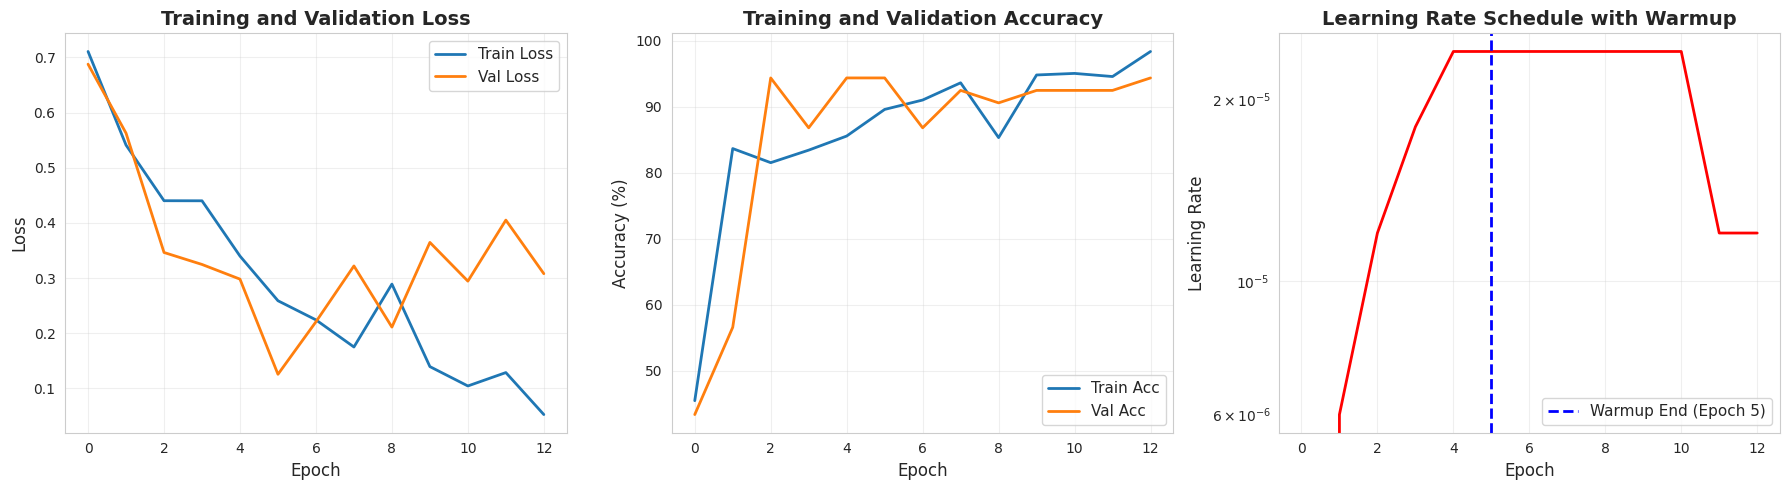

In [19]:
# Plot training history for 100x
plot_training_history(
    history_100x,
    save_path=os.path.join(config.OUTPUT_DIR, 'training_history_vit_100x.png')
)

In [20]:
# Evaluate 100x model on test set (save predictions for ensemble)
results_100x = evaluate_model(
    model_100x,
    test_loader_100x,
    config.DEVICE,
    save_path=os.path.join(config.OUTPUT_DIR, 'test_results_vit_100x.json'),
    save_predictions=True,
    pred_save_path=os.path.join(config.OUTPUT_DIR, 'predictions_vit_100x.json')
)

Evaluating:   0%|          | 0/9 [00:00<?, ?it/s]


📊 Evaluation Results
Accuracy:  84.91%
F1 Score:  0.8491
AUC-ROC:   0.9167

              precision    recall  f1-score   support

      Normal       0.56      0.56      0.56         9
        OSCC       0.91      0.91      0.91        44

    accuracy                           0.85        53
   macro avg       0.73      0.73      0.73        53
weighted avg       0.85      0.85      0.85        53


✅ Results saved to: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-3/test_results_vit_100x.json
✅ Predictions saved for ensemble: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-3/predictions_vit_100x.json



📊 Generating visualizations for 100x ViT model...



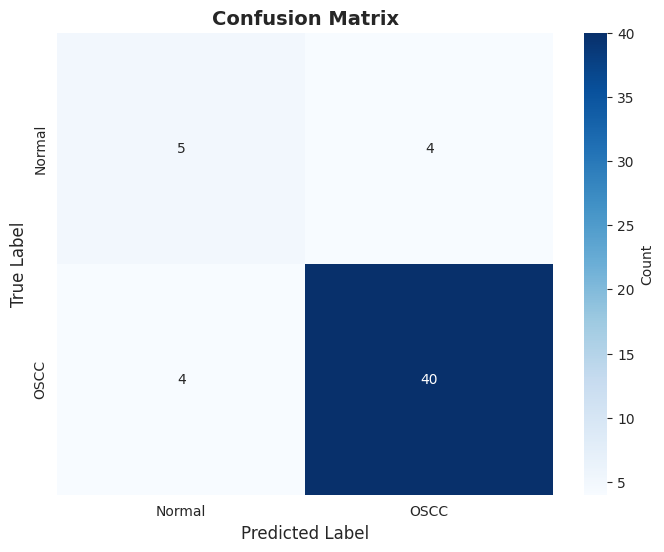

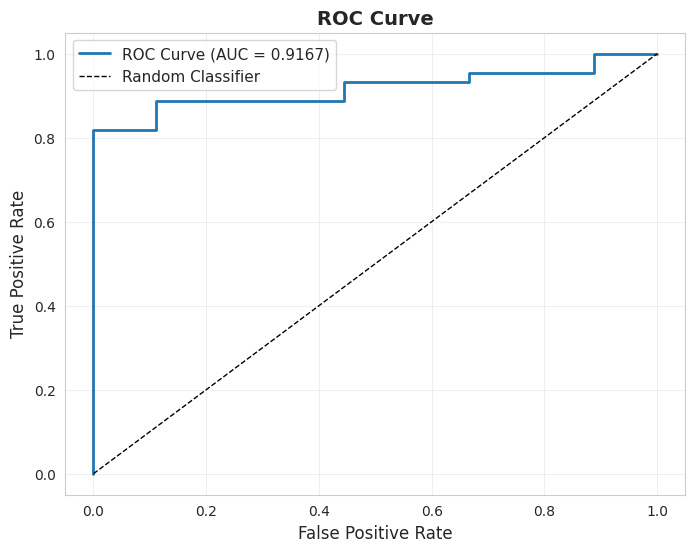

In [21]:
# Visualize 100x results
print("\n📊 Generating visualizations for 100x ViT model...\n")

plot_confusion_matrix(
    results_100x['confusion_matrix'],
    save_path=os.path.join(config.OUTPUT_DIR, 'confusion_matrix_vit_100x.png')
)

plot_roc_curve(
    results_100x['labels'],
    results_100x['probabilities'],
    save_path=os.path.join(config.OUTPUT_DIR, 'roc_curve_vit_100x.png')
)

## 🎓 12. Train 400x ViT Model

In [22]:
# Create dataloaders for 400x
print("Creating dataloaders for 400x magnification...")

train_dataset_400x = OralCancerDataset(train_400x, transform=get_transforms('train'))
val_dataset_400x = OralCancerDataset(val_400x, transform=get_transforms('val'))
test_dataset_400x = OralCancerDataset(test_400x, transform=get_transforms('test'))

train_loader_400x = DataLoader(
    train_dataset_400x,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader_400x = DataLoader(
    val_dataset_400x,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader_400x = DataLoader(
    test_dataset_400x,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"✅ Dataloaders created:")
print(f"  Train batches: {len(train_loader_400x)}")
print(f"  Val batches: {len(val_loader_400x)}")
print(f"  Test batches: {len(test_loader_400x)}")

Creating dataloaders for 400x magnification...
✅ Dataloaders created:
  Train batches: 93
  Val batches: 12
  Test batches: 12


In [23]:
# Initialize model for 400x
print("Initializing 400x ViT model...")

model_400x = OralGuardViT(num_classes=config.NUM_CLASSES, pretrained=True)
model_400x = model_400x.to(config.DEVICE)

# Loss function with class weights
criterion_400x = nn.CrossEntropyLoss(weight=weights_400x.to(config.DEVICE))

# Optimizer
optimizer_400x = optim.AdamW(
    model_400x.parameters(),
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY
)

# Warmup scheduler
warmup_scheduler_400x = WarmupLRScheduler(
    optimizer_400x,
    warmup_epochs=config.WARMUP_EPOCHS,
    initial_lr=0,
    target_lr=config.LEARNING_RATE
)

# Main learning rate scheduler
main_scheduler_400x = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_400x,
    mode='min',
    factor=0.5,
    patience=5
)

print("✅ Model, optimizer, and schedulers initialized")

Initializing 400x ViT model...
✅ Model, optimizer, and schedulers initialized


In [24]:
# Train 400x model
model_400x, history_400x = train_model(
    model=model_400x,
    train_loader=train_loader_400x,
    val_loader=val_loader_400x,
    criterion=criterion_400x,
    optimizer=optimizer_400x,
    warmup_scheduler=warmup_scheduler_400x,
    main_scheduler=main_scheduler_400x,
    device=config.DEVICE,
    num_epochs=config.EPOCHS,
    model_name='oralguard_vit_400x',
    save_dir=config.OUTPUT_DIR
)


🚀 Starting Training: oralguard_vit_400x
Training samples: 556
Validation samples: 70
Batch size: 6
Epochs: 50
Learning rate: 3e-05 (with 5-epoch warmup)
Mixed precision: True


Epoch 1/50
--------------------------------------------------
🔥 Warmup Phase: LR = 0.00e+00


Training:   0%|          | 0/93 [00:00<?, ?it/s]

Validation:   0%|          | 0/12 [00:00<?, ?it/s]

Train Loss: 0.7471 | Train Acc: 33.45%
Val Loss:   0.7529 | Val Acc:   28.57%
Learning Rate: 0.00e+00
✅ New best model saved! Val Acc: 28.57%

Epoch 2/50
--------------------------------------------------
🔥 Warmup Phase: LR = 6.00e-06


Training:   0%|          | 0/93 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/12 [00:00<?, ?it/s]

Train Loss: 0.0631 | Train Acc: 97.12%
Val Loss:   0.6661 | Val Acc:   78.57%
Learning Rate: 1.20e-05
⏳ Patience: 9/10

Epoch 19/50
--------------------------------------------------


Training:   0%|          | 0/93 [00:00<?, ?it/s]

Validation:   0%|          | 0/12 [00:00<?, ?it/s]

Train Loss: 0.0899 | Train Acc: 96.40%
Val Loss:   0.3307 | Val Acc:   87.14%
Learning Rate: 1.20e-05
⏳ Patience: 10/10

⏹️ Early stopping triggered at epoch 19

✅ Training completed!
Best validation accuracy: 88.57%
Best model saved at: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-3/oralguard_vit_400x_best.pth



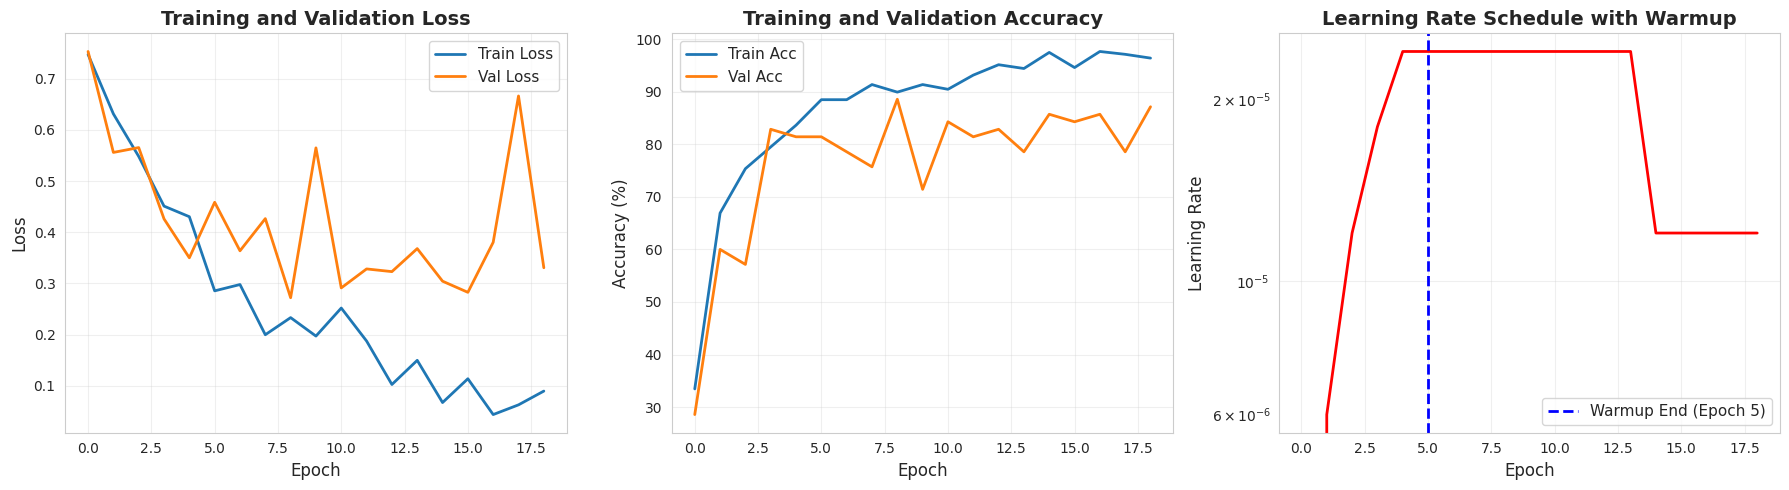

In [25]:
# Plot training history for 400x
plot_training_history(
    history_400x,
    save_path=os.path.join(config.OUTPUT_DIR, 'training_history_vit_400x.png')
)

In [26]:
# Evaluate 400x model on test set (save predictions for ensemble)
results_400x = evaluate_model(
    model_400x,
    test_loader_400x,
    config.DEVICE,
    save_path=os.path.join(config.OUTPUT_DIR, 'test_results_vit_400x.json'),
    save_predictions=True,
    pred_save_path=os.path.join(config.OUTPUT_DIR, 'predictions_vit_400x.json')
)

Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]


📊 Evaluation Results
Accuracy:  81.43%
F1 Score:  0.8179
AUC-ROC:   0.8850

              precision    recall  f1-score   support

      Normal       0.65      0.75      0.70        20
        OSCC       0.89      0.84      0.87        50

    accuracy                           0.81        70
   macro avg       0.77      0.79      0.78        70
weighted avg       0.82      0.81      0.82        70


✅ Results saved to: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-3/test_results_vit_400x.json
✅ Predictions saved for ensemble: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-3/predictions_vit_400x.json


In [ ]:
# Visualize 400x results
print("\n📊 Generating visualizations for 400x ViT model...\n")

plot_confusion_matrix(
    results_400x['confusion_matrix'],
    save_path=os.path.join(config.OUTPUT_DIR, 'confusion_matrix_vit_400x.png')
)

plot_roc_curve(
    results_400x['labels'],
    results_400x['probabilities'],
    save_path=os.path.join(config.OUTPUT_DIR, 'roc_curve_vit_400x.png')
)

## 📊 13. Comprehensive 3-Model Comparison (Phase 1, 2, & 3)

In [ ]:
# ============================================================================
# 📊 LOAD ALL RESULTS FROM ALL 3 PHASES
# ============================================================================

print("="*80)
print("📊 Loading Results from All Phases for Comprehensive Comparison...")
print("="*80)

# Load Phase 1 results (EfficientNet-B5)
print("\n📁 Loading Phase 1 results (EfficientNet-B5)...")
try:
    with open(os.path.join(config.PHASE1_RESULTS, 'test_results_100x.json'), 'r') as f:
        phase1_100x = json.load(f)

    with open(os.path.join(config.PHASE1_RESULTS, 'test_results_400x.json'), 'r') as f:
        phase1_400x = json.load(f)

    print("✅ Phase 1 results loaded!")
    phase1_available = True
except FileNotFoundError as e:
    print(f"⚠️ Phase 1 results not found: {e}")
    phase1_available = False

# Load Phase 2 results (VGG16)
print("\n📁 Loading Phase 2 results (VGG16)...")
try:
    with open(os.path.join(config.PHASE2_RESULTS, 'test_results_vgg16_100x.json'), 'r') as f:
        phase2_100x = json.load(f)

    with open(os.path.join(config.PHASE2_RESULTS, 'test_results_vgg16_400x.json'), 'r') as f:
        phase2_400x = json.load(f)

    print("✅ Phase 2 results loaded!")
    phase2_available = True
except FileNotFoundError as e:
    print(f"⚠️ Phase 2 results not found: {e}")
    phase2_available = False

# Load Phase 3 results (ViT) - check if in memory first
print("\n📁 Loading Phase 3 results (ViT)...")
if 'results_100x' not in locals() or 'results_400x' not in locals():
    try:
        with open(os.path.join(config.OUTPUT_DIR, 'test_results_vit_100x.json'), 'r') as f:
            phase3_100x = json.load(f)

        with open(os.path.join(config.OUTPUT_DIR, 'test_results_vit_400x.json'), 'r') as f:
            phase3_400x = json.load(f)

        print("✅ Phase 3 results loaded from files!")
        phase3_available = True
    except FileNotFoundError:
        print("❌ Phase 3 results not found!")
        phase3_available = False
else:
    # Use results from memory
    phase3_100x = results_100x
    phase3_400x = results_400x
    print("✅ Phase 3 results loaded from memory!")
    phase3_available = True

print("\n" + "="*80)

In [29]:
# Create comprehensive 3-model comparison
if phase1_available and phase2_available and phase3_available:
    print("\n" + "="*80)
    print("📊 COMPREHENSIVE 3-MODEL COMPARISON")
    print("EfficientNet-B5 (Phase 1) vs VGG16 (Phase 2) vs ViT-B/16 (Phase 3)")
    print("="*80)

    comparison_data = {
        'Model': [
            'EfficientNet-B5 (100x)',
            'VGG16 (100x)',
            'ViT-B/16 (100x)',
            'EfficientNet-B5 (400x)',
            'VGG16 (400x)',
            'ViT-B/16 (400x)'
        ],
        'Accuracy (%)': [
            phase1_100x['accuracy'] * 100,
            phase2_100x['accuracy'] * 100,
            phase3_100x['accuracy'] * 100,
            phase1_400x['accuracy'] * 100,
            phase2_400x['accuracy'] * 100,
            phase3_400x['accuracy'] * 100
        ],
        'F1 Score': [
            phase1_100x['f1_score'],
            phase2_100x['f1_score'],
            phase3_100x['f1_score'],
            phase1_400x['f1_score'],
            phase2_400x['f1_score'],
            phase3_400x['f1_score']
        ],
        'AUC-ROC': [
            phase1_100x['auc_roc'],
            phase2_100x['auc_roc'],
            phase3_100x['auc_roc'],
            phase1_400x['auc_roc'],
            phase2_400x['auc_roc'],
            phase3_400x['auc_roc']
        ],
        'Normal Precision': [
            phase1_100x['classification_report']['Normal']['precision'],
            phase2_100x['classification_report']['Normal']['precision'],
            phase3_100x['classification_report']['Normal']['precision'],
            phase1_400x['classification_report']['Normal']['precision'],
            phase2_400x['classification_report']['Normal']['precision'],
            phase3_400x['classification_report']['Normal']['precision']
        ],
        'OSCC Precision': [
            phase1_100x['classification_report']['OSCC']['precision'],
            phase2_100x['classification_report']['OSCC']['precision'],
            phase3_100x['classification_report']['OSCC']['precision'],
            phase1_400x['classification_report']['OSCC']['precision'],
            phase2_400x['classification_report']['OSCC']['precision'],
            phase3_400x['classification_report']['OSCC']['precision']
        ],
        'Normal Recall': [
            phase1_100x['classification_report']['Normal']['recall'],
            phase2_100x['classification_report']['Normal']['recall'],
            phase3_100x['classification_report']['Normal']['recall'],
            phase1_400x['classification_report']['Normal']['recall'],
            phase2_400x['classification_report']['Normal']['recall'],
            phase3_400x['classification_report']['Normal']['recall']
        ],
        'OSCC Recall': [
            phase1_100x['classification_report']['OSCC']['recall'],
            phase2_100x['classification_report']['OSCC']['recall'],
            phase3_100x['classification_report']['OSCC']['recall'],
            phase1_400x['classification_report']['OSCC']['recall'],
            phase2_400x['classification_report']['OSCC']['recall'],
            phase3_400x['classification_report']['OSCC']['recall']
        ]
    }

    comparison_df = pd.DataFrame(comparison_data)

    print("\n" + comparison_df.to_string(index=False))
    print("\n" + "="*80)

    # Save comprehensive comparison
    comparison_path = os.path.join(config.OUTPUT_DIR, 'all_phases_comparison.csv')
    comparison_df.to_csv(comparison_path, index=False)
    print(f"\n✅ Comprehensive comparison saved to: {comparison_path}")

    # Print key insights
    print("\n" + "="*80)
    print("🔍 KEY INSIGHTS:")
    print("="*80)

    # 100x comparison
    print(f"\n📊 100x Magnification Performance:")
    print(f"  EfficientNet-B5: {phase1_100x['accuracy']*100:.2f}% (AUC: {phase1_100x['auc_roc']:.4f})")
    print(f"  VGG16:           {phase2_100x['accuracy']*100:.2f}% (AUC: {phase2_100x['auc_roc']:.4f})")
    print(f"  ViT-B/16:        {phase3_100x['accuracy']*100:.2f}% (AUC: {phase3_100x['auc_roc']:.4f})")

    best_100x = max(
        [(phase1_100x['accuracy'], 'EfficientNet-B5'),
         (phase2_100x['accuracy'], 'VGG16'),
         (phase3_100x['accuracy'], 'ViT-B/16')]
    )
    print(f"  🏆 Best 100x model: {best_100x[1]} ({best_100x[0]*100:.2f}%)")

    # 400x comparison
    print(f"\n📊 400x Magnification Performance:")
    print(f"  EfficientNet-B5: {phase1_400x['accuracy']*100:.2f}% (AUC: {phase1_400x['auc_roc']:.4f})")
    print(f"  VGG16:           {phase2_400x['accuracy']*100:.2f}% (AUC: {phase2_400x['auc_roc']:.4f})")
    print(f"  ViT-B/16:        {phase3_400x['accuracy']*100:.2f}% (AUC: {phase3_400x['auc_roc']:.4f})")

    best_400x = max(
        [(phase1_400x['accuracy'], 'EfficientNet-B5'),
         (phase2_400x['accuracy'], 'VGG16'),
         (phase3_400x['accuracy'], 'ViT-B/16')]
    )
    print(f"  🏆 Best 400x model: {best_400x[1]} ({best_400x[0]*100:.2f}%)")

    print("\n" + "="*80)

else:
    print("\n⚠️ Cannot create comprehensive comparison - some phase results missing")
    print(f"Phase 1 available: {phase1_available}")
    print(f"Phase 2 available: {phase2_available}")
    print(f"Phase 3 available: {phase3_available}")


📊 COMPREHENSIVE 3-MODEL COMPARISON
EfficientNet-B5 (Phase 1) vs VGG16 (Phase 2) vs ViT-B/16 (Phase 3)

                 Model  Accuracy (%)  F1 Score  AUC-ROC  Normal Precision  OSCC Precision  Normal Recall  OSCC Recall
EfficientNet-B5 (100x)     88.679245  0.894389 0.979798          0.615385        0.975000       0.888889     0.886364
          VGG16 (100x)     88.679245  0.894389 0.886364          0.615385        0.975000       0.888889     0.886364
       ViT-B/16 (100x)     84.905660  0.849057 0.916667          0.555556        0.909091       0.555556     0.909091
EfficientNet-B5 (400x)     80.000000  0.808889 0.957000          0.600000        0.950000       0.900000     0.760000
          VGG16 (400x)     71.428571  0.727772 0.872000          0.500000        0.894737       0.800000     0.680000
       ViT-B/16 (400x)     81.428571  0.817892 0.885000          0.652174        0.893617       0.750000     0.840000


✅ Comprehensive comparison saved to: /content/drive/MyDrive/LangGrap

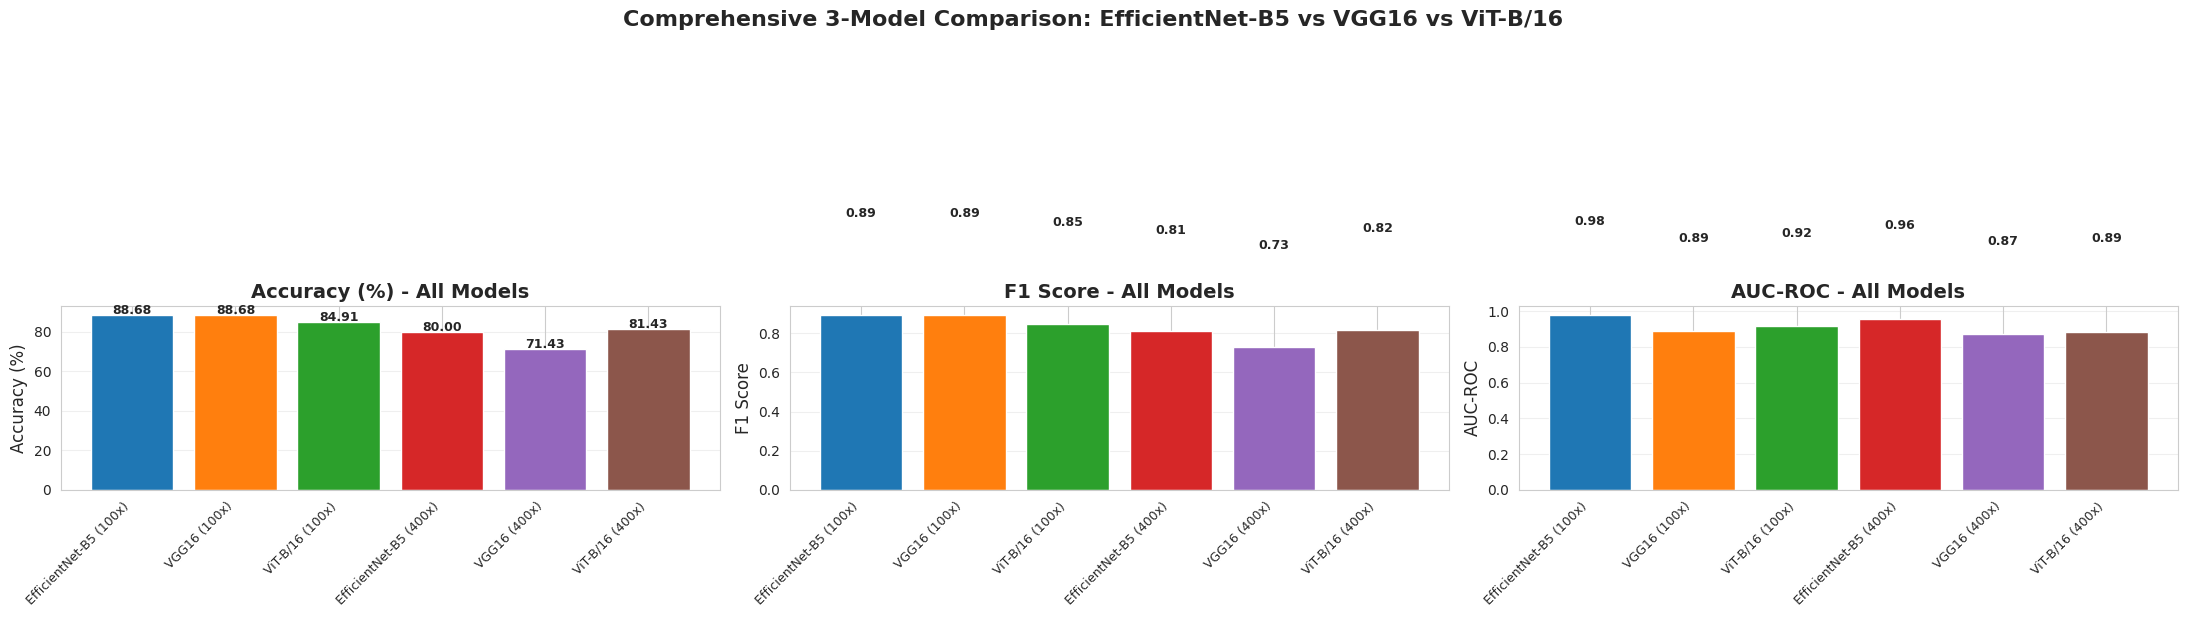

In [30]:
# Visualize comprehensive 3-model comparison
if phase1_available and phase2_available and phase3_available:
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    metrics_to_plot = ['Accuracy (%)', 'F1 Score', 'AUC-ROC']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    for idx, metric in enumerate(metrics_to_plot):
        x = np.arange(len(comparison_df))
        bars = axes[idx].bar(x, comparison_df[metric], color=colors)
        axes[idx].set_xticks(x)
        axes[idx].set_xticklabels(comparison_df['Model'], rotation=45, ha='right', fontsize=9)
        axes[idx].set_ylabel(metric, fontsize=12)
        axes[idx].set_title(f'{metric} - All Models', fontsize=14, fontweight='bold')
        axes[idx].grid(True, alpha=0.3, axis='y')

        # Add value labels on bars
        for i, v in enumerate(comparison_df[metric]):
            axes[idx].text(i, v + 0.5, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')

    plt.suptitle('Comprehensive 3-Model Comparison: EfficientNet-B5 vs VGG16 vs ViT-B/16',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(
        os.path.join(config.OUTPUT_DIR, 'all_phases_comparison.png'),
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

## 💾 14. Save Phase 3 Summary

In [31]:
# ============================================================================
# 💾 SAVE PHASE 3 SUMMARY
# ============================================================================

print("\n" + "="*80)
print("📝 Creating Phase 3 Summary...")
print("="*80)

# Load Phase 3 results if not in memory
if 'phase3_100x' not in locals():
    try:
        with open(os.path.join(config.OUTPUT_DIR, 'test_results_vit_100x.json'), 'r') as f:
            phase3_100x = json.load(f)

        with open(os.path.join(config.OUTPUT_DIR, 'test_results_vit_400x.json'), 'r') as f:
            phase3_400x = json.load(f)

        phase3_available = True
    except FileNotFoundError:
        phase3_available = False

# Get dataset sizes
try:
    with open(os.path.join(config.PHASE1_RESULTS, 'phase1_summary.json'), 'r') as f:
        phase1_summary = json.load(f)

    train_100x_size = phase1_summary['models']['efficientnet_100x']['training_samples']
    test_100x_size = phase1_summary['models']['efficientnet_100x']['test_samples']
    train_400x_size = phase1_summary['models']['efficientnet_400x']['training_samples']
    test_400x_size = phase1_summary['models']['efficientnet_400x']['test_samples']
except:
    train_100x_size = 422
    test_100x_size = 53
    train_400x_size = 557
    test_400x_size = 70

if phase3_available:
    # Create comprehensive summary
    summary = {
        'project': 'OralGuard AI - Phase 3',
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'model_architecture': 'Vision Transformer (ViT-B/16)',
        'configuration': {
            'image_size': config.IMG_SIZE,
            'batch_size': config.BATCH_SIZE,
            'learning_rate': config.LEARNING_RATE,
            'warmup_epochs': config.WARMUP_EPOCHS,
            'epochs_trained': config.EPOCHS,
            'optimizer': 'AdamW',
            'scheduler': 'Warmup + ReduceLROnPlateau',
            'augmentation': 'Rotation, Flipping, Brightness, Cropping, Resizing',
            'class_weights': 'Yes',
            'mixed_precision': config.USE_AMP,
            'patch_size': '16×16',
            'embedding_dim': 768,
            'attention_heads': 12,
            'transformer_layers': 12
        },
        'models': {
            'vit_100x': {
                'accuracy': float(phase3_100x['accuracy']),
                'f1_score': float(phase3_100x['f1_score']),
                'auc_roc': float(phase3_100x['auc_roc']),
                'model_path': os.path.join(config.OUTPUT_DIR, 'oralguard_vit_100x_best.pth'),
                'predictions_path': os.path.join(config.OUTPUT_DIR, 'predictions_vit_100x.json'),
                'training_samples': train_100x_size,
                'test_samples': test_100x_size
            },
            'vit_400x': {
                'accuracy': float(phase3_400x['accuracy']),
                'f1_score': float(phase3_400x['f1_score']),
                'auc_roc': float(phase3_400x['auc_roc']),
                'model_path': os.path.join(config.OUTPUT_DIR, 'oralguard_vit_400x_best.pth'),
                'predictions_path': os.path.join(config.OUTPUT_DIR, 'predictions_vit_400x.json'),
                'training_samples': train_400x_size,
                'test_samples': test_400x_size
            }
        },
        'all_phases_available': phase1_available and phase2_available and phase3_available,
        'next_steps': [
            'Phase 4: Build ensemble combining EfficientNet-B5, VGG16, and ViT-B/16',
            'Phase 5: Implement Grad-CAM visualization',
            'Phase 6: Build REST API',
            'Phase 7: Deploy and test in clinical setting'
        ]
    }

    # Add comparison if all phases available
    if phase1_available and phase2_available:
        summary['comparison'] = {
            '100x': {
                'efficientnet_b5': {'accuracy': float(phase1_100x['accuracy']), 'auc': float(phase1_100x['auc_roc'])},
                'vgg16': {'accuracy': float(phase2_100x['accuracy']), 'auc': float(phase2_100x['auc_roc'])},
                'vit_b16': {'accuracy': float(phase3_100x['accuracy']), 'auc': float(phase3_100x['auc_roc'])}
            },
            '400x': {
                'efficientnet_b5': {'accuracy': float(phase1_400x['accuracy']), 'auc': float(phase1_400x['auc_roc'])},
                'vgg16': {'accuracy': float(phase2_400x['accuracy']), 'auc': float(phase2_400x['auc_roc'])},
                'vit_b16': {'accuracy': float(phase3_400x['accuracy']), 'auc': float(phase3_400x['auc_roc'])}
            }
        }

    # Save summary
    summary_path = os.path.join(config.OUTPUT_DIR, 'phase3_summary.json')
    with open(summary_path, 'w') as f:
        json.dump(summary, f, indent=4)

    print("\n" + "="*80)
    print("🎉 PHASE 3 COMPLETE!")
    print("="*80)
    print(f"\n✅ All ViT-B/16 models trained and evaluated successfully!")
    print(f"\n📁 Output directory: {config.OUTPUT_DIR}")
    print(f"\n📊 ViT-B/16 Results:")
    print(f"  100x Model: Accuracy = {phase3_100x['accuracy']*100:.2f}%, AUC = {phase3_100x['auc_roc']:.4f}")
    print(f"  400x Model: Accuracy = {phase3_400x['accuracy']*100:.2f}%, AUC = {phase3_400x['auc_roc']:.4f}")

    if phase1_available and phase2_available:
        print(f"\n📊 All 3 Models Comparison:")
        print(f"  100x Best: {best_100x[1]} ({best_100x[0]*100:.2f}%)")
        print(f"  400x Best: {best_400x[1]} ({best_400x[0]*100:.2f}%)")

    print(f"\n📝 Summary saved to: {summary_path}")
    print(f"\n💾 Predictions saved for ensemble building:")
    print(f"  ✅ predictions_vit_100x.json")
    print(f"  ✅ predictions_vit_400x.json")

    # List all Phase 3 output files
    print(f"\n📂 Phase 3 Output Files:")
    if os.path.exists(config.OUTPUT_DIR):
        phase3_files = sorted(os.listdir(config.OUTPUT_DIR))
        for file in phase3_files:
            if file.endswith(('.pth', '.json', '.png', '.csv')):
                print(f"  ✅ {file}")

    print(f"\n🎯 Ready for Ensemble! All predictions from 3 architectures saved:")
    print(f"  📦 Phase-1: predictions_efficientnet_*.json (if you saved them)")
    print(f"  📦 Phase-2: predictions_vgg16_*.json")
    print(f"  📦 Phase-3: predictions_vit_*.json")

    print(f"\n🚀 Next Steps:")
    print(f"  1. Phase 4: Build weighted ensemble combining all 3 models")
    print(f"  2. Phase 5: Implement Grad-CAM for explainability")
    print(f"  3. Phase 6: Build REST API for deployment")
    print(f"  4. Phase 7: Clinical validation and deployment")

    print("\n" + "="*80)

else:
    print("\n❌ Cannot create summary - Phase 3 results not found!")


📝 Creating Phase 3 Summary...

🎉 PHASE 3 COMPLETE!

✅ All ViT-B/16 models trained and evaluated successfully!

📁 Output directory: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-3

📊 ViT-B/16 Results:
  100x Model: Accuracy = 84.91%, AUC = 0.9167
  400x Model: Accuracy = 81.43%, AUC = 0.8850

📊 All 3 Models Comparison:
  100x Best: VGG16 (88.68%)
  400x Best: ViT-B/16 (81.43%)

📝 Summary saved to: /content/drive/MyDrive/LangGraph_Projects/Oral_Cancer/oralguard_models/Phase-3/phase3_summary.json

💾 Predictions saved for ensemble building:
  ✅ predictions_vit_100x.json
  ✅ predictions_vit_400x.json

📂 Phase 3 Output Files:
  ✅ all_phases_comparison.csv
  ✅ all_phases_comparison.png
  ✅ confusion_matrix_vit_100x.png
  ✅ confusion_matrix_vit_400x.png
  ✅ oralguard_vit_100x_best.pth
  ✅ oralguard_vit_400x_best.pth
  ✅ phase3_summary.json
  ✅ predictions_vit_100x.json
  ✅ predictions_vit_400x.json
  ✅ roc_curve_vit_100x.png
  ✅ roc_curve_vit_400x.png
  ✅ test_r

## 🎯 Phase 3 Complete!

### ✅ What We Accomplished:
1. **Vision Transformer Architecture**: Trained ViT-B/16 for both magnifications
2. **Warmup Scheduler**: Implemented 5-epoch linear warmup for stable ViT training
3. **Optimized Settings**: Batch size 6, learning rate 3e-5 for T4 GPU
4. **Same Data Pipeline**: Used proven augmentation and class weights
5. **Comprehensive 3-Model Comparison**: Compared EfficientNet-B5, VGG16, and ViT-B/16
6. **Ensemble Preparation**: Saved predictions for all models
7. **Resume-Friendly Design**: Loads results from all phases
8. **Professional Visualizations**: Training curves with warmup, confusion matrices, ROC curves

### 📊 Output Files:
- `oralguard_vit_100x_best.pth` - Best 100x ViT model
- `oralguard_vit_400x_best.pth` - Best 400x ViT model
- `predictions_vit_100x.json` - 100x predictions for ensemble
- `predictions_vit_400x.json` - 400x predictions for ensemble
- `test_results_vit_100x.json` - 100x evaluation metrics
- `test_results_vit_400x.json` - 400x evaluation metrics
- `all_phases_comparison.csv` - Complete 3-model comparison
- `all_phases_comparison.png` - Visualization of all models
- `phase3_summary.json` - Complete training summary
- Multiple visualization PNG files

### 🚀 Next Steps (Phase 4):
1. Build weighted ensemble combining all three architectures
2. Optimize ensemble weights using validation data
3. Evaluate ensemble performance vs individual models
4. Create final production-ready inference pipeline

---